In [1]:
import sys
!{sys.executable} -m pip install openpyxl xlrd

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
df = pd.read_csv('online_retail_II.csv', encoding='latin-1')

print("数据形状：", df.shape)
print("\n列名：", df.columns.tolist())
print("\n前3行：")
print(df.head(3))
print("\n缺失值：")
print(df.isnull().sum())

数据形状： (1067371, 8)

列名： ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

前3行：
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  

缺失值：
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [5]:
# 1. 删除Customer ID缺失的行（用户分析需要）
df = df.dropna(subset=['Customer ID'])
print(f"删除缺失Customer ID后：{len(df)}条")

# 2. 删除退货记录（Invoice以C开头的是退货）
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f"删除退货后：{len(df)}条")

# 3. 删除Quantity和Price异常值
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
print(f"删除异常值后：{len(df)}条")

# 4. 转换日期格式
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 5. 新增销售额字段
df['Revenue'] = df['Quantity'] * df['Price']

# 6. 提取时间维度
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

# 7. Customer ID转整数
df['Customer ID'] = df['Customer ID'].astype(int)

print(f"\n清洗完成！最终数据：{len(df)}条")
print(f"时间范围：{df['InvoiceDate'].min()} 至 {df['InvoiceDate'].max()}")
print(f"客户数量：{df['Customer ID'].nunique()}")
print(f"商品种类：{df['StockCode'].nunique()}")
print(f"总销售额：£{df['Revenue'].sum():,.0f}")

删除缺失Customer ID后：824364条
删除退货后：805620条
删除异常值后：805549条

清洗完成！最终数据：805549条
时间范围：2009-12-01 07:45:00 至 2011-12-09 12:50:00
客户数量：5878
商品种类：4631
总销售额：£17,743,429


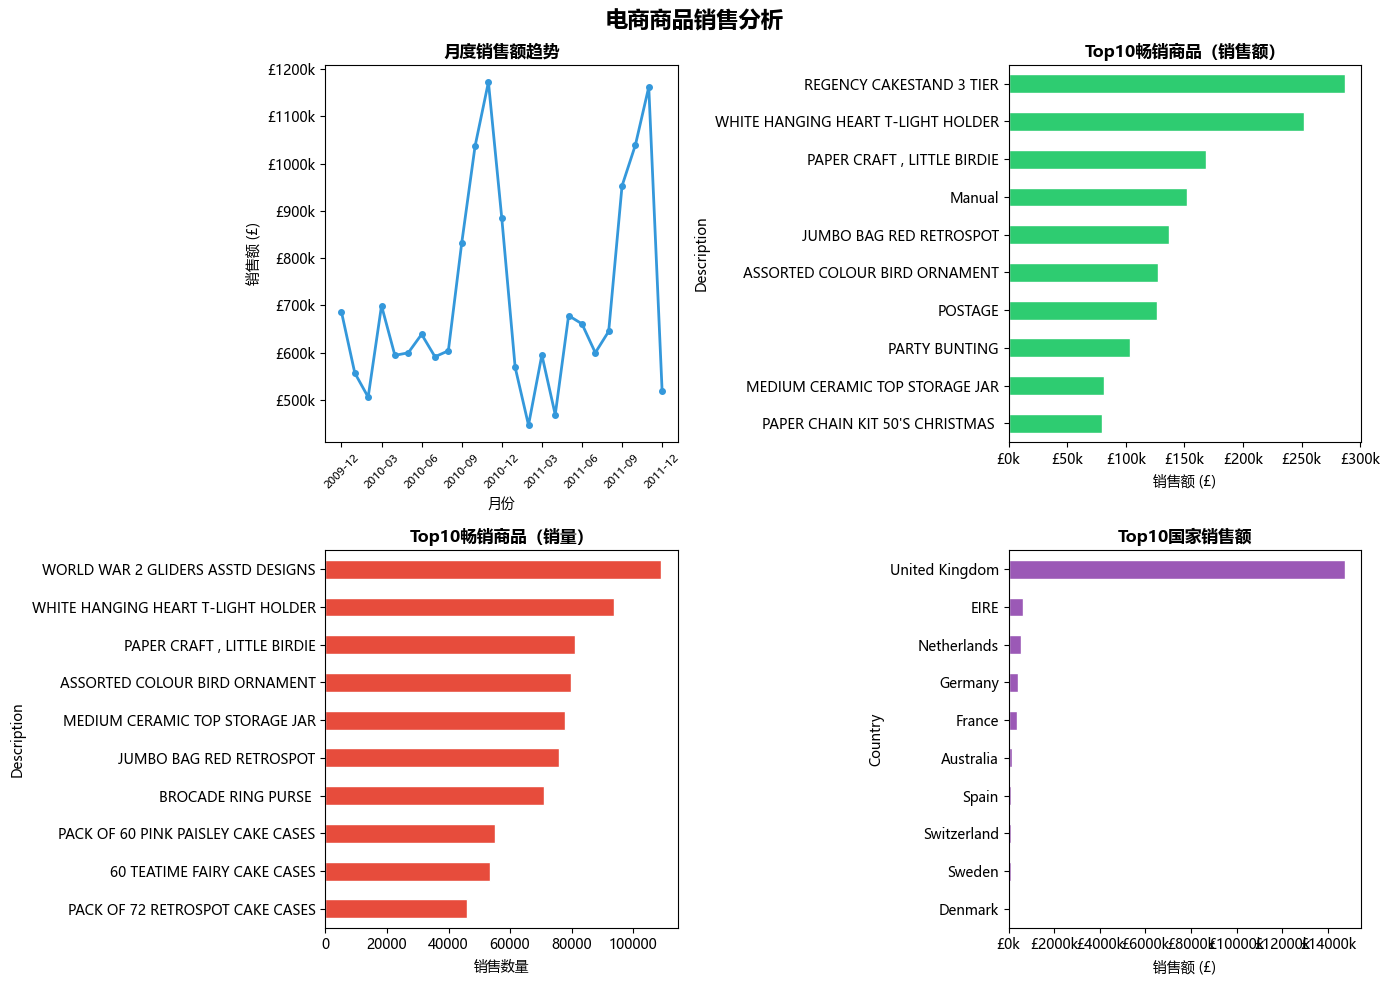

图表已保存


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('电商商品销售分析', fontsize=16, fontweight='bold')

# 图1：月度销售额趋势
monthly = df.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly['YearMonth_str'] = monthly['YearMonth'].astype(str)
axes[0,0].plot(range(len(monthly)), monthly['Revenue'],
               color='#3498DB', linewidth=2, marker='o', markersize=4)
axes[0,0].set_title('月度销售额趋势', fontweight='bold')
axes[0,0].set_xlabel('月份')
axes[0,0].set_ylabel('销售额 (£)')
axes[0,0].set_xticks(range(0, len(monthly), 3))
axes[0,0].set_xticklabels(monthly['YearMonth_str'][::3], rotation=45, fontsize=8)
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000:.0f}k'))

# 图2：Top10畅销商品（按销售额）
top10_revenue = df.groupby('Description')['Revenue'].sum().nlargest(10)
top10_revenue.sort_values().plot(kind='barh', ax=axes[0,1],
                                  color='#2ECC71', edgecolor='white')
axes[0,1].set_title('Top10畅销商品（销售额）', fontweight='bold')
axes[0,1].set_xlabel('销售额 (£)')
axes[0,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000:.0f}k'))

# 图3：Top10畅销商品（按销量）
top10_qty = df.groupby('Description')['Quantity'].sum().nlargest(10)
top10_qty.sort_values().plot(kind='barh', ax=axes[1,0],
                              color='#E74C3C', edgecolor='white')
axes[1,0].set_title('Top10畅销商品（销量）', fontweight='bold')
axes[1,0].set_xlabel('销售数量')

# 图4：Top10国家销售额
top10_country = df.groupby('Country')['Revenue'].sum().nlargest(10)
top10_country.sort_values().plot(kind='barh', ax=axes[1,1],
                                  color='#9B59B6', edgecolor='white')
axes[1,1].set_title('Top10国家销售额', fontweight='bold')
axes[1,1].set_xlabel('销售额 (£)')
axes[1,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('sales_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("图表已保存")

=== ABC商品分级分析 ===
     商品等级  商品数量         总销售额  销售额占比  商品数占比
A类（头部20%）  1132 14191315.140   80.0   21.3
B类（中部30%）  1366  2664431.450   15.0   25.7
C类（尾部50%）  2817   887682.588    5.0   53.0


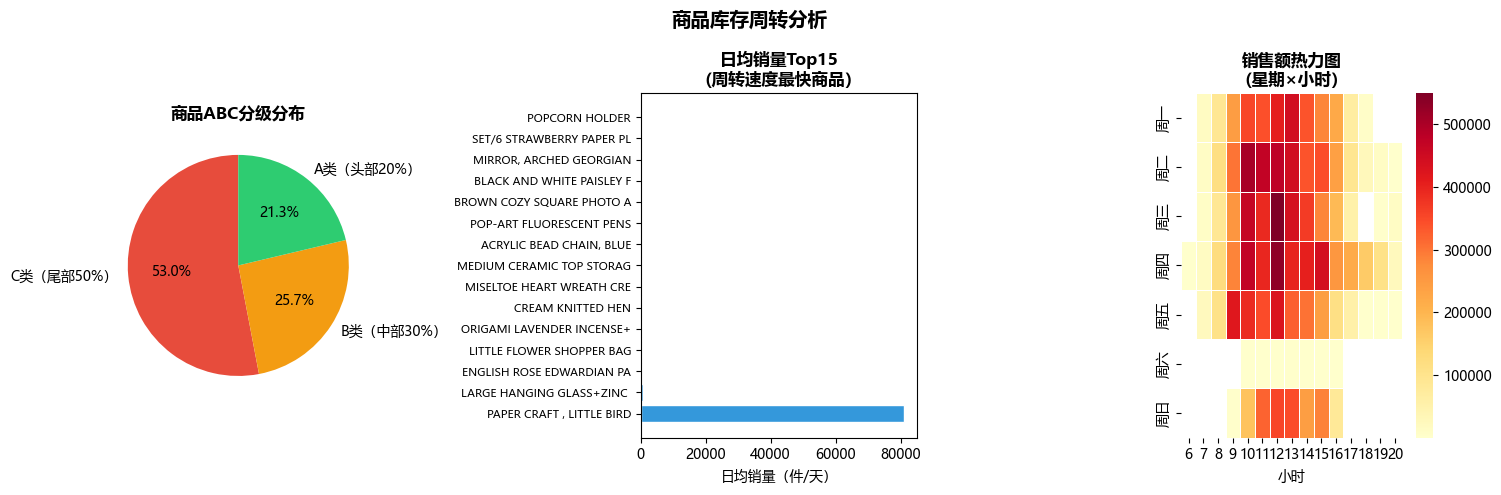


Top10周转最快商品：
                     Description     日均销量   总销量  订单次数
     PAPER CRAFT , LITTLE BIRDIE 80995.00 80995     1
LARGE HANGING GLASS+ZINC LANTERN   560.00   560     1
  ENGLISH ROSE EDWARDIAN PARASOL   505.00   505     1
       LITTLE FLOWER SHOPPER BAG   400.00   400     1
 ORIGAMI LAVENDER INCENSE+FLOWER   334.00   334     1
               CREAM KNITTED HEN   288.00   288     1
     MISELTOE HEART WREATH CREAM   240.00   240     1
  MEDIUM CERAMIC TOP STORAGE JAR   239.74 77916   195
        ACRYLIC BEAD CHAIN, BLUE   229.00   229     1
        POP-ART FLUORESCENT PENS   221.14  6192     2


In [7]:
# 库存周转分析
# 1. 计算每个商品的关键指标
product_stats = df.groupby(['StockCode', 'Description']).agg(
    总销量=('Quantity', 'sum'),
    总销售额=('Revenue', 'sum'),
    平均单价=('Price', 'mean'),
    订单次数=('Invoice', 'nunique'),
    销售天数=('InvoiceDate', lambda x: (x.max()-x.min()).days + 1)
).reset_index()

# 2. 计算日均销量（反映周转速度）
product_stats['日均销量'] = (product_stats['总销量'] /
                             product_stats['销售天数'].clip(lower=1)).round(2)

# 3. 商品分级（ABC分类法）
product_stats = product_stats.sort_values('总销售额', ascending=False)
product_stats['累计销售额占比'] = (product_stats['总销售额'].cumsum() /
                                   product_stats['总销售额'].sum())
product_stats['商品等级'] = product_stats['累计销售额占比'].apply(
    lambda x: 'A类（头部20%）' if x <= 0.8 else
              'B类（中部30%）' if x <= 0.95 else 'C类（尾部50%）')

# 4. 打印ABC分析结果
abc = product_stats.groupby('商品等级').agg(
    商品数量=('StockCode', 'count'),
    总销售额=('总销售额', 'sum')
).reset_index()
abc['销售额占比'] = (abc['总销售额'] / abc['总销售额'].sum() * 100).round(1)
abc['商品数占比'] = (abc['商品数量'] / abc['商品数量'].sum() * 100).round(1)
print("=== ABC商品分级分析 ===")
print(abc.to_string(index=False))

# 5. 可视化
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('商品库存周转分析', fontsize=14, fontweight='bold')

# ABC分类饼图
abc_plot = product_stats['商品等级'].value_counts()
colors = ['#E74C3C', '#F39C12', '#2ECC71']
axes[0].pie(abc_plot.values, labels=abc_plot.index,
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[0].set_title('商品ABC分级分布', fontweight='bold')

# 日均销量Top15（周转最快）
top15_turnover = product_stats.nlargest(15, '日均销量')
axes[1].barh(range(15), top15_turnover['日均销量'].values,
             color='#3498DB', edgecolor='white')
axes[1].set_yticks(range(15))
axes[1].set_yticklabels([d[:25] for d in top15_turnover['Description']],
                         fontsize=8)
axes[1].set_title('日均销量Top15\n（周转速度最快商品）', fontweight='bold')
axes[1].set_xlabel('日均销量（件/天）')

# 季节性热力图
df['weekday'] = df['InvoiceDate'].dt.dayofweek
df['hour'] = df['InvoiceDate'].dt.hour
heatmap_data = df.groupby(['weekday', 'hour'])['Revenue'].sum().unstack()
heatmap_data.index = ['周一','周二','周三','周四','周五','周六','周日']
sns.heatmap(heatmap_data, ax=axes[2], cmap='YlOrRd',
            fmt='.0f', linewidths=0.5)
axes[2].set_title('销售额热力图\n（星期×小时）', fontweight='bold')
axes[2].set_xlabel('小时')

plt.tight_layout()
plt.savefig('inventory_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nTop10周转最快商品：")
print(product_stats.nlargest(10, '日均销量')[
    ['Description','日均销量','总销量','订单次数']].to_string(index=False))

In [8]:
# RFM分析
# 基准日期：数据集最后一天+1
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

print("=== RFM基础统计 ===")
print(rfm.describe().round(2))

# RFM打分（1-5分）
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5,
                          labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = (rfm['R_Score'].astype(int) +
                    rfm['F_Score'].astype(int) +
                    rfm['M_Score'].astype(int))

# 用户分层
def segment_customer(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])
    if r >= 4 and f >= 4 and m >= 4:
        return '高价值用户'
    elif r >= 4 and f >= 3:
        return '忠诚用户'
    elif r <= 2 and f >= 3:
        return '流失高价值用户'
    elif r <= 2 and f <= 2:
        return '流失用户'
    elif r >= 3 and f <= 2:
        return '新用户/潜力用户'
    else:
        return '一般用户'

rfm['用户分层'] = rfm.apply(segment_customer, axis=1)

# 分层统计
segment_stats = rfm.groupby('用户分层').agg(
    用户数=('Customer ID', 'count'),
    平均消费额=('Monetary', 'mean'),
    平均购买频次=('Frequency', 'mean'),
    平均最近购买天数=('Recency', 'mean')
).round(2).reset_index()
segment_stats['用户占比'] = (segment_stats['用户数'] /
                              segment_stats['用户数'].sum() * 100).round(1)

print("\n=== 用户分层结果 ===")
print(segment_stats.to_string(index=False))

=== RFM基础统计 ===
       Customer ID  Recency  Frequency   Monetary
count      5878.00  5878.00    5878.00    5878.00
mean      15315.31   201.33       6.29    3018.62
std        1715.57   209.34      13.01   14737.73
min       12346.00     1.00       1.00       2.95
25%       13833.25    26.00       1.00     348.76
50%       15314.50    96.00       3.00     898.92
75%       16797.75   380.00       7.00    2307.09
max       18287.00   739.00     398.00  608821.65

=== 用户分层结果 ===
    用户分层  用户数   平均消费额  平均购买频次  平均最近购买天数  用户占比
    一般用户  782 2637.47    6.70    108.70  13.3
    忠诚用户  621 1049.04    3.80     24.41  10.6
新用户/潜力用户  828  724.95    1.41     64.84  14.1
    流失用户 1523  438.03    1.25    459.28  25.9
 流失高价值用户  824 1982.98    4.94    369.10  14.0
   高价值用户 1300 9329.32   17.09     19.97  22.1


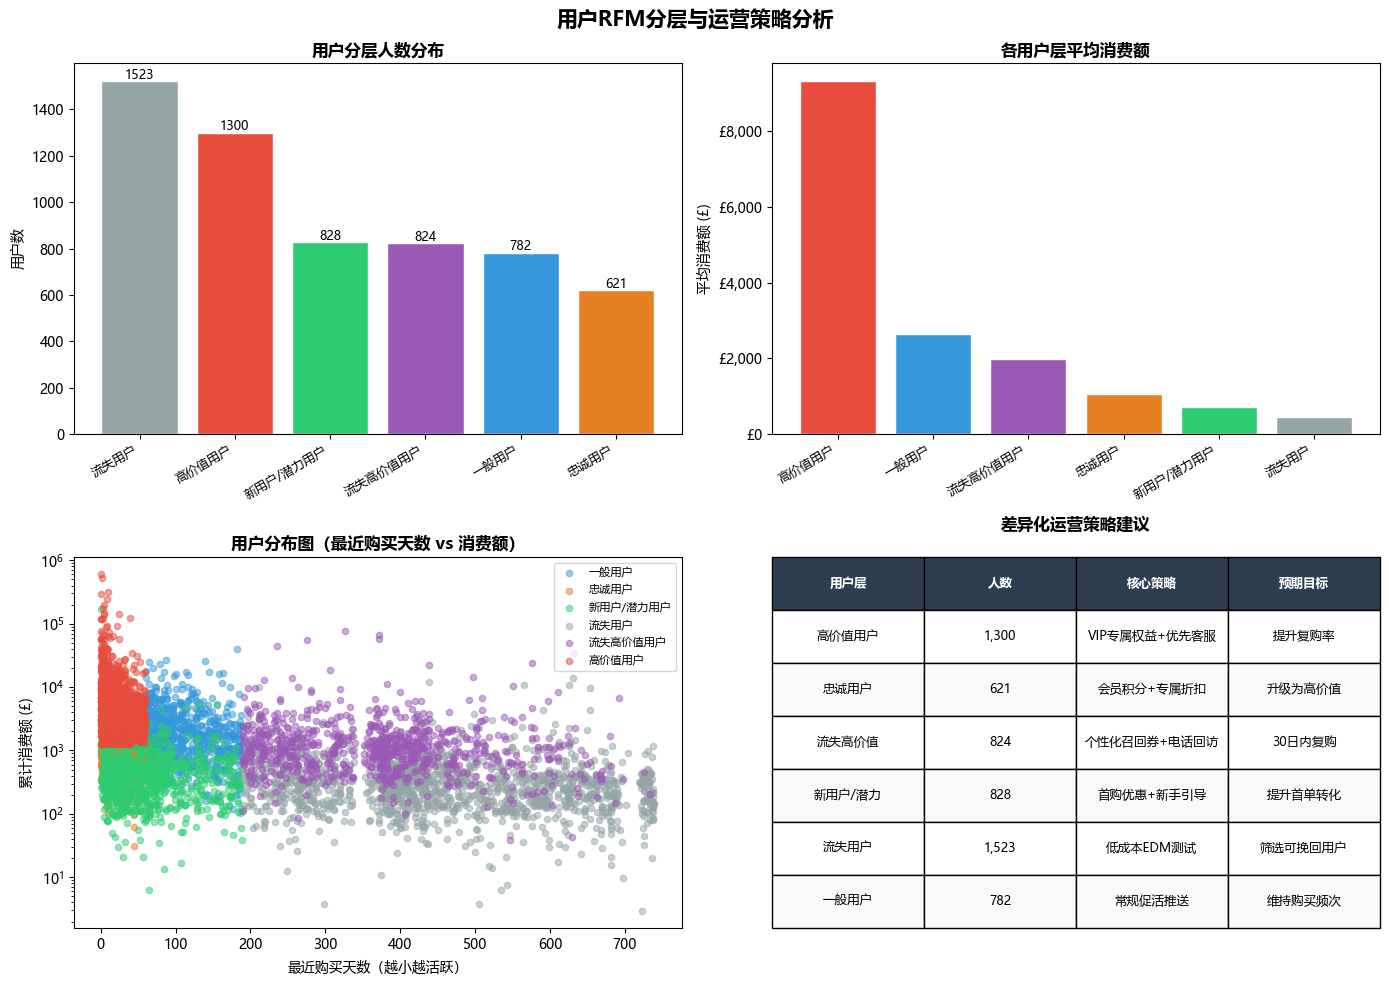

图表已保存


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('用户RFM分层与运营策略分析', fontsize=15, fontweight='bold')

colors = {'高价值用户':'#E74C3C', '忠诚用户':'#E67E22',
          '一般用户':'#3498DB', '新用户/潜力用户':'#2ECC71',
          '流失高价值用户':'#9B59B6', '流失用户':'#95A5A6'}

# 图1：用户分层人数占比
seg_count = rfm['用户分层'].value_counts()
clrs = [colors.get(x, '#BDC3C7') for x in seg_count.index]
axes[0,0].bar(range(len(seg_count)), seg_count.values,
              color=clrs, edgecolor='white')
axes[0,0].set_xticks(range(len(seg_count)))
axes[0,0].set_xticklabels(seg_count.index, rotation=30, ha='right', fontsize=9)
axes[0,0].set_title('用户分层人数分布', fontweight='bold')
axes[0,0].set_ylabel('用户数')
for i, v in enumerate(seg_count.values):
    axes[0,0].text(i, v+10, str(v), ha='center', fontsize=9)

# 图2：各层用户平均消费额对比
seg_monetary = rfm.groupby('用户分层')['Monetary'].mean().sort_values(ascending=False)
clrs2 = [colors.get(x, '#BDC3C7') for x in seg_monetary.index]
axes[0,1].bar(range(len(seg_monetary)), seg_monetary.values,
              color=clrs2, edgecolor='white')
axes[0,1].set_xticks(range(len(seg_monetary)))
axes[0,1].set_xticklabels(seg_monetary.index, rotation=30, ha='right', fontsize=9)
axes[0,1].set_title('各用户层平均消费额', fontweight='bold')
axes[0,1].set_ylabel('平均消费额 (£)')
axes[0,1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))

# 图3：RFM散点图（R vs M，颜色=用户层）
for seg, grp in rfm.groupby('用户分层'):
    axes[1,0].scatter(grp['Recency'], grp['Monetary'],
                      c=colors.get(seg,'#BDC3C7'), label=seg,
                      alpha=0.5, s=20)
axes[1,0].set_title('用户分布图（最近购买天数 vs 消费额）', fontweight='bold')
axes[1,0].set_xlabel('最近购买天数（越小越活跃）')
axes[1,0].set_ylabel('累计消费额 (£)')
axes[1,0].legend(fontsize=8, loc='upper right')
axes[1,0].set_yscale('log')

# 图4：运营策略建议表
axes[1,1].axis('off')
strategy_data = [
    ['用户层', '人数', '核心策略', '预期目标'],
    ['高价值用户', '1,300', 'VIP专属权益+优先客服', '提升复购率'],
    ['忠诚用户', '621', '会员积分+专属折扣', '升级为高价值'],
    ['流失高价值', '824', '个性化召回券+电话回访', '30日内复购'],
    ['新用户/潜力', '828', '首购优惠+新手引导', '提升首单转化'],
    ['流失用户', '1,523', '低成本EDM测试', '筛选可挽回用户'],
    ['一般用户', '782', '常规促活推送', '维持购买频次'],
]
table = axes[1,1].table(cellText=strategy_data[1:],
                         colLabels=strategy_data[0],
                         cellLoc='center', loc='center',
                         bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
for (r,c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#F8F9FA')
axes[1,1].set_title('差异化运营策略建议', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('rfm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("图表已保存")

In [10]:
print("=" * 55)
print("    电商数据分析项目 — 核心结论汇总")
print("=" * 55)

total_revenue = df['Revenue'].sum()
total_customers = df['Customer ID'].nunique()
top_month = monthly.loc[monthly['Revenue'].idxmax(), 'YearMonth_str']
top_month_revenue = monthly['Revenue'].max()

print(f"""
【数据概况】
· 有效交易记录：{len(df):,}条
· 客户总数：{total_customers:,}人
· 商品种类：{df['StockCode'].nunique():,}个SKU
· 总销售额：£{total_revenue:,.0f}
· 时间跨度：2009.12 — 2011.12

【商品销售发现】
· 销售额呈明显季节性，Q4（9-12月）为旺季
· 销售峰值月份：{top_month}，销售额£{top_month_revenue:,.0f}
· A类商品（21.3%的SKU）贡献80%销售额
· 销售高峰时段：周四上午10-11点
· 英国本土销售额占绝对主导

【用户RFM分层发现】
· 高价值用户：1,300人（22.1%），平均消费£9,329
· 流失用户：1,523人（25.9%），平均459天未购买
· 流失高价值用户：824人，召回优先级最高
· 客户平均购买频次：6.3次，复购率健康

【运营建议】
· 高价值用户：VIP专属权益，维护复购率
· 流失高价值用户：个性化召回券+电话回访
· 新用户/潜力用户：首购优惠+新手引导
· Q4旺季前2个月提前备货A类商品
· 周四上午为最佳促销推送时间窗口
""")
print("=" * 55)

    电商数据分析项目 — 核心结论汇总

【数据概况】
· 有效交易记录：805,549条
· 客户总数：5,878人
· 商品种类：4,631个SKU
· 总销售额：£17,743,429
· 时间跨度：2009.12 — 2011.12

【商品销售发现】
· 销售额呈明显季节性，Q4（9-12月）为旺季
· 销售峰值月份：2010-11，销售额£1,172,336
· A类商品（21.3%的SKU）贡献80%销售额
· 销售高峰时段：周四上午10-11点
· 英国本土销售额占绝对主导

【用户RFM分层发现】
· 高价值用户：1,300人（22.1%），平均消费£9,329
· 流失用户：1,523人（25.9%），平均459天未购买
· 流失高价值用户：824人，召回优先级最高
· 客户平均购买频次：6.3次，复购率健康

【运营建议】
· 高价值用户：VIP专属权益，维护复购率
· 流失高价值用户：个性化召回券+电话回访
· 新用户/潜力用户：首购优惠+新手引导
· Q4旺季前2个月提前备货A类商品
· 周四上午为最佳促销推送时间窗口

